In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
df = pd.concat([train, test], ignore_index = True)

In [5]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
129876,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
129877,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
129878,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [6]:
df.drop(columns = ['Unnamed: 0', 'id'], inplace = True)

In [7]:
df.drop_duplicates(inplace = True)

In [8]:
df.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [9]:
df.dropna(inplace = True)

In [10]:
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

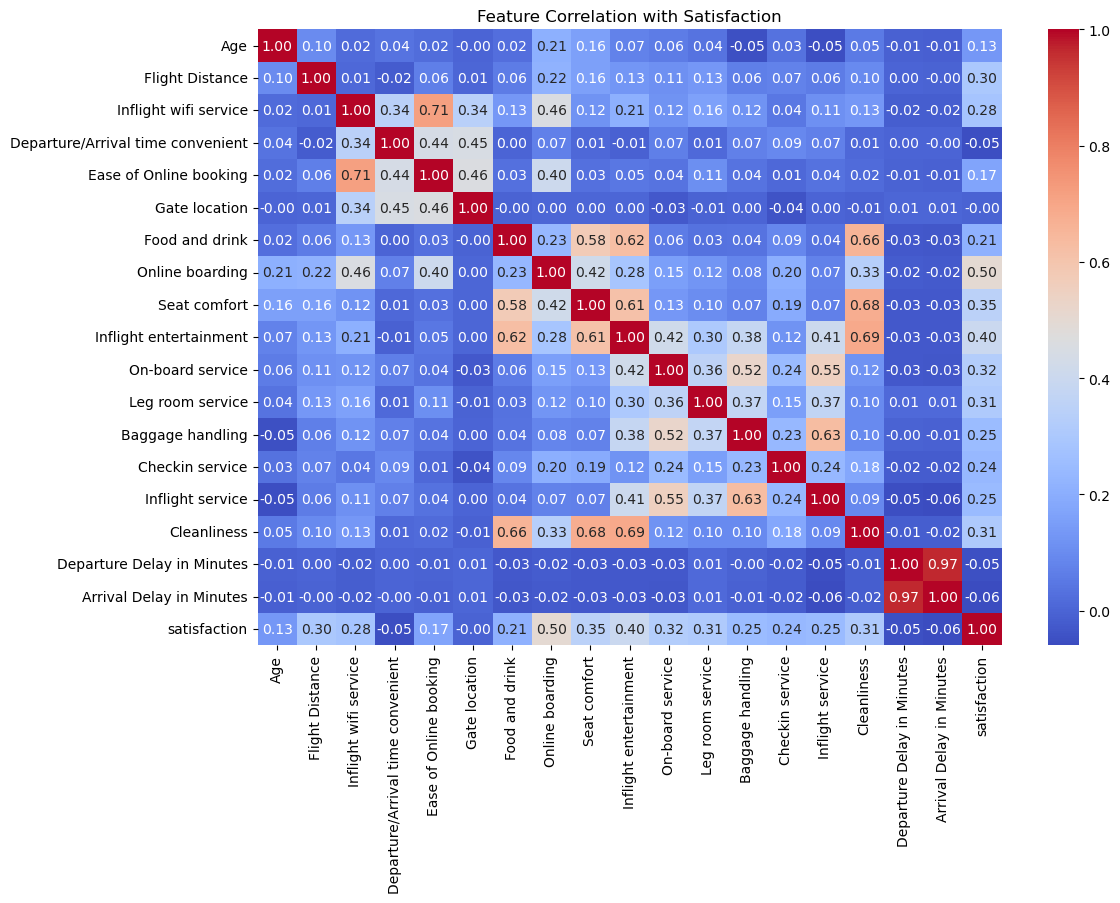

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation with Satisfaction')
plt.show()

In [12]:
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

In [13]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
num_cols = X.select_dtypes(include='number').columns.tolist()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [17]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
results = []
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor), 
        ('model', model)
        ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": round(acc, 4)})
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))

display(pd.DataFrame(results).sort_values("Accuracy", ascending=False))



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14668
           1       0.87      0.84      0.85     11230

    accuracy                           0.88     25898
   macro avg       0.87      0.87      0.87     25898
weighted avg       0.88      0.88      0.87     25898


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     14668
           1       0.97      0.94      0.95     11230

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     14668
           1       0.94      0.92      0.93     11230

    accuracy                           0.94     25898
   macro avg       0.94      0.94      0.94     2

,Model,Accuracy
1,Random Forest,0.9610
2,Gradient Boosting,0.9397
0,Logistic Regression,0.8752


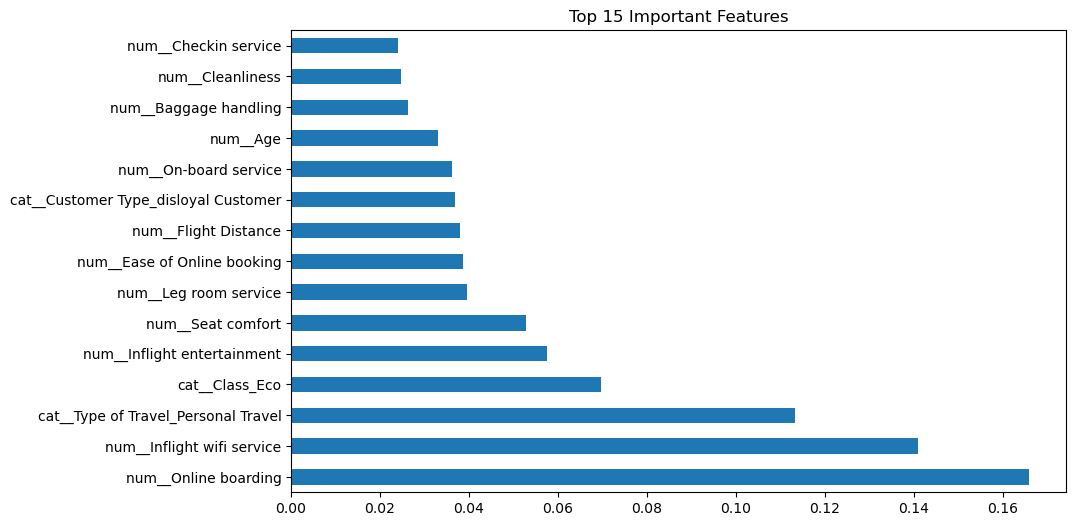

In [26]:
best = Pipeline([('prep', preprocessor), ('model', RandomForestClassifier(n_estimators=200, random_state=42))])
best.fit(X_train, y_train)

importances = pd.Series(
    best.named_steps['model'].feature_importances_,
    index=best.named_steps['prep'].get_feature_names_out()
).sort_values(ascending=False).head(15)

importances.plot(kind='barh', figsize=(10, 6), title='Top 15 Important Features')
plt.show()

In [27]:
import joblib

final_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])
final_pipe.fit(X, y)

joblib.dump(final_pipe, 'satisfaction_model.pkl')

['satisfaction_model.pkl']